<a href="https://colab.research.google.com/github/ramcharan0816/hotel-review-sentiment-analysis/blob/main/Hotel_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import re
import nltk

In [65]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

-> Importing necessary modules from
NLTK.  

* 'stopwords' tool for improving the efficiency an dfocus of text processing taks by filtering common words.
* 'PorterStemmer' tool for  text normalization.
* 'TfidfVectorizer' tool is used to convert raw text data into numerical form.
* Logistic Regression is used for binary classification and accuracy_score function to evaluate the performance of the classification.

* WordNet and the Open Multilingual Wordnet (OMW) are used to map relationships between words (synonyms, hyponyms)





In [66]:
data=pd.read_csv("hotel_reviews.csv")
data.head()

,Review,Rating
0,The room was spacious and very clean,5
1,Excellent service and very polite staff,5
2,Rooms are not cleaned properly,3
3,Comfortable bed and peaceful environment,4
4,There is no availability of Hot water,2


-> The datset is loaded, data.head() gives a quick preveiw of dataset.

In [67]:
print("Total Reviews:",len(data))
print(data.columns)


Total Reviews: 145
Index(['Review', 'Rating'], dtype='object')


In [68]:
def get_sentiment(rating):
  if rating>=4:
    return "Positive"
  else:
    return "Negative"
data['Sentiment'] = data['Rating'].apply(get_sentiment)

data[['Rating','Sentiment']].head()

,Rating,Sentiment
0,5,Positive
1,5,Positive
2,3,Negative
3,4,Positive
4,2,Negative


-> Ratings are converted to cateogaries as the model needs labels like Positive/Negative

In [69]:
data['Sentiment'].value_counts()

,count
Sentiment,
Negative,73
Positive,72


-> The dataset is almost perfectly balanced and the model can learn better

In [70]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


In [71]:
def preprocess(text):
    text = text.lower() #the text is coverted to lowercase
    text = re.sub('[^a-z]', ' ', text) #removes punctuations in the text
    words = text.split() #text is split into words
    lemmatizer=WordNetLemmatizer()
    stop_words=set(stopwords.words('english'))
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 1]

    return " ".join(words)


In [72]:
data['Clean_Review'] = data['Review'].apply(preprocess)

data[['Review','Clean_Review']].head()


,Review,Clean_Review
0,The room was spacious and very clean,room spacious clean
1,Excellent service and very polite staff,excellent service polite staff
2,Rooms are not cleaned properly,room cleaned properly
3,Comfortable bed and peaceful environment,comfortable bed peaceful environment
4,There is no availability of Hot water,availability hot water


Pre-processing helps in improving accuracy and the root word can be found easily.

In [73]:
vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(data['Clean_Review'])


-> The text is converted to numbers using TfidfVectorizer as machine understand numbers.

In [74]:
y = data['Sentiment'].map({'Positive':1, 'Negative':0})


-> The Labels are converted into numbers.

In [75]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)



Model Accuracy: 0.7241379310344828


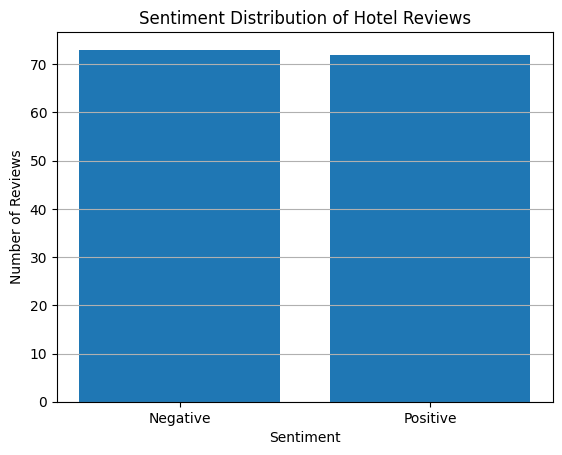

In [76]:
import matplotlib.pyplot as plt

sentiment_counts = data['Sentiment'].value_counts()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Distribution of Hotel Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(axis='y')
plt.show()

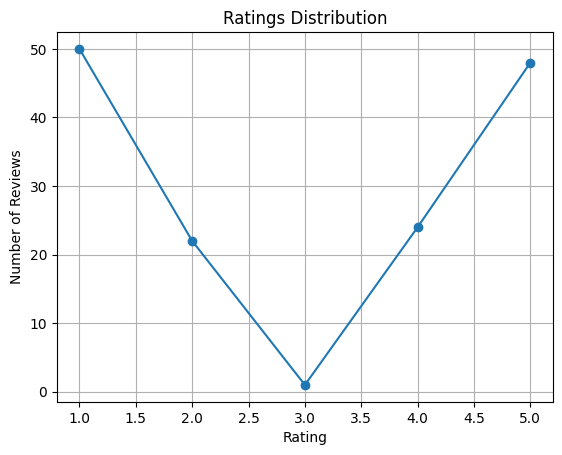

In [77]:
rating_counts = data['Rating'].value_counts().sort_index()

plt.figure()
plt.plot(rating_counts.index, rating_counts.values, marker='o')
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.grid()
plt.show()

In [78]:
def predict_review(review):
    review = preprocess(review)
    vector = vectorizer.transform([review])
    prediction = model.predict(vector)[0]

    if prediction == 1:
        print("Positive ")
    else:
        print("Negative ")


-> The model is trained and we can try our own reviews.

In [79]:
predict_review("the staff is very rude")

Negative 





*  This project uses NLP techniques and TF-IDF to process hotel reviews and classify them as positive or negative using Logistic Regression.




